# 02. Brent–WTI Market Data Pipeline Walkthrough

This notebook documents the market-data pipeline built for
[issue #4](https://github.com/andrewheekin/finm37000-grp-6-trading/issues/4):
a cleaned, timestamp-aligned dataset of WTI (CL) and Brent (BZ) futures
prices that the rest of the strategy is developed on.

It is written for two audiences:

1. **Teammates** who want to load the data and start building — see the
   *Loading the data* sections and the column glossary.
2. **Reviewers/instructors** who want to see what was pulled, how gaps and
   mismatches are handled, and what the spread looks like.

Everything here reads from the local parquet outputs of the pipeline
(`doit pull_databento clean_mbp1`); no network access or API key is needed
to re-run this notebook once those files exist.

In [1]:
import pandas as pd

from clean_mbp1 import (
    FRONT_SPREAD,
    load_aligned,
    load_grid,
    load_spread_events,
)
from plot_spread_diagnostics import (
    plot_activity_by_hour,
    plot_histogram,
    plot_pacf,
    plot_rolling_deviations,
    plot_week_series,
    plot_width_by_hour,
    rolling_deviations,
)
from pull_databento import OUTRIGHTS, PILOT_END, PILOT_START, SPREADS

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print(f"Pilot window: {PILOT_START} to {PILOT_END} (end exclusive)")
print(f"Outrights:    {OUTRIGHTS}")
print(f"Spreads:      {SPREADS}")

Pilot window: 2026-06-01 to 2026-06-06 (end exclusive)
Outrights:    ['CL.v.0', 'BZ.v.0']
Spreads:      ['CLN6-BZQ6', 'CLQ6-BZQ6', 'CLU6-BZU6']


## 1. What was pulled

All data comes from Databento, dataset `GLBX.MDP3` (CME Globex), schema
`mbp-1` (top-of-book quotes and trades, one record per book event), over a
pilot week 2026-06-01 → 2026-06-06 (Mon–Fri, end exclusive).

Two kinds of instruments:

- **Continuous front-month outrights** `CL.v.0` (WTI) and `BZ.v.0` (Brent),
  rolled by volume. The `.v.0` vs `.n.0` decision and supporting
  measurements are in issue #20 — the open-interest rule (`.n.0`) mapped to
  December contracts rather than the front month, so it was not used.
- **Exchange-listed Brent–WTI spread instruments** (`CLN6-BZQ6`,
  `CLQ6-BZQ6`, `CLU6-BZU6`). These trade as single instruments with their
  own order book, so they are an execution venue for the spread itself,
  with one bid/ask rather than two legs to cross.

Raw DBN files are cached one-per-symbol under `DATA_DIR/databento`;
re-running the pull with a warm cache costs nothing.

## 2. The aligned dataset

The headline deliverable for issue #4: CL and BZ on one UTC time index,
with the synthetic spread computed from the legs and the front listed
spread's book alongside. Two grid frequencies are produced (`1s` and `1m`);
the 1-minute grid is shown here.

In [2]:
aligned = load_aligned("1m")
print(f"shape: {aligned.shape}")
print(f"index: {aligned.index.min()}  ->  {aligned.index.max()}  ({aligned.index.tz})")
aligned.head(3)

shape: (7021, 34)
index: 2026-06-01 00:00:00+00:00  ->  2026-06-05 21:00:00+00:00  (UTC)


,cl_bid_px_00,cl_ask_px_00,cl_bid_sz_00,cl_ask_sz_00,cl_mid,cl_instrument_id,cl_n_events,cl_n_trades,cl_volume,cl_is_roll_date,bz_bid_px_00,bz_ask_px_00,bz_bid_sz_00,bz_ask_sz_00,bz_mid,bz_instrument_id,bz_n_events,bz_n_trades,bz_volume,bz_is_roll_date,ls_bid_px_00,ls_ask_px_00,ls_bid_sz_00,ls_ask_sz_00,ls_mid,ls_instrument_id,ls_n_events,ls_n_trades,ls_volume,ls_is_roll_date,synth_mid,synth_bid,synth_ask,is_roll_date
ts_recv,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00+00:00,89.51,89.54,3.0,4.0,89.525,777566.0,416,40,46,False,92.99,93.03,1.0,2.0,93.010,755267.0,169,4,9,False,-3.49,-3.47,2.0,1.0,-3.480,42016777.0,79,0,0,False,-3.485,-3.52,-3.45,False
2026-06-01 00:01:00+00:00,89.59,89.60,2.0,11.0,89.595,777566.0,271,18,25,False,93.05,93.10,3.0,1.0,93.075,755267.0,104,0,0,False,-3.51,-3.47,3.0,2.0,-3.490,42016777.0,36,0,0,False,-3.480,-3.51,-3.45,False
2026-06-01 00:02:00+00:00,89.52,89.55,3.0,2.0,89.535,777566.0,248,18,19,False,93.01,93.06,2.0,3.0,93.035,755267.0,66,0,0,False,-3.51,-3.48,3.0,3.0,-3.495,42016777.0,26,0,0,False,-3.500,-3.54,-3.46,False


### Column glossary

| prefix / column | meaning |
|---|---|
| `cl_*` | WTI leg (`CL.v.0`): top-of-book `bid_px_00`, `ask_px_00`, sizes, `mid` |
| `bz_*` | Brent leg (`BZ.v.0`): same layout |
| `ls_*` | front listed spread instrument's book (`CLN6-BZQ6`) |
| `synth_mid` | `cl_mid - bz_mid` — the synthetic Brent–WTI spread |
| `synth_bid` | `cl_bid - bz_ask` — what you receive selling the synthetic spread |
| `synth_ask` | `cl_ask - bz_bid` — what you pay buying the synthetic spread |
| `*_n_events` | book events in the bucket; `0` means the quote is carried forward |
| `*_n_trades`, `*_volume` | trades and traded contracts in the bucket (never filled) |
| `*_instrument_id` | underlying contract id (tracks rolls) |
| `is_roll_date` | date on which either leg's mapped contract changed |

### Missing-data conventions

- Quote columns are the **last quote per bucket**, forward-filled for at
  most 600 seconds; beyond that (e.g. the daily maintenance break) the
  bucket stays `NaN` rather than carrying a stale quote.
- Activity columns (`n_events`, `n_trades`, `volume`) are per-bucket facts
  and are **never** forward-filled, so `n_events == 0` cleanly marks any
  bucket whose quote is a carry-forward.
- Crossed/locked books are **flagged** (`is_crossed` in the event series),
  not dropped — downstream code decides what to exclude.
- The legs are combined with an **outer join**, so no timestamps are
  silently discarded; both-legs coverage is measurable directly:

In [3]:
key_cols = ["cl_mid", "bz_mid", "synth_mid", "ls_bid_px_00"]
coverage = aligned[key_cols].notna().mean().round(4).to_frame("non-null share")
carried = (aligned["cl_n_events"].eq(0) & aligned["cl_mid"].notna()).mean()
print(f"CL buckets whose quote is a carry-forward: {carried:.1%}")
coverage

CL buckets whose quote is a carry-forward: 1.0%


,non-null share
cl_mid,0.9785
bz_mid,0.9781
synth_mid,0.9761
ls_bid_px_00,0.9793


## 3. What the spread looks like

The question the diagnostics address: does the spread visually mean-revert,
and at what horizon? These are the same figures produced by
`doit spread_diagnostics`; here they render inline with commentary.

First, the synthetic spread mid over the pilot week, colored by 4-hour UTC
window (dashed verticals separate calendar days):

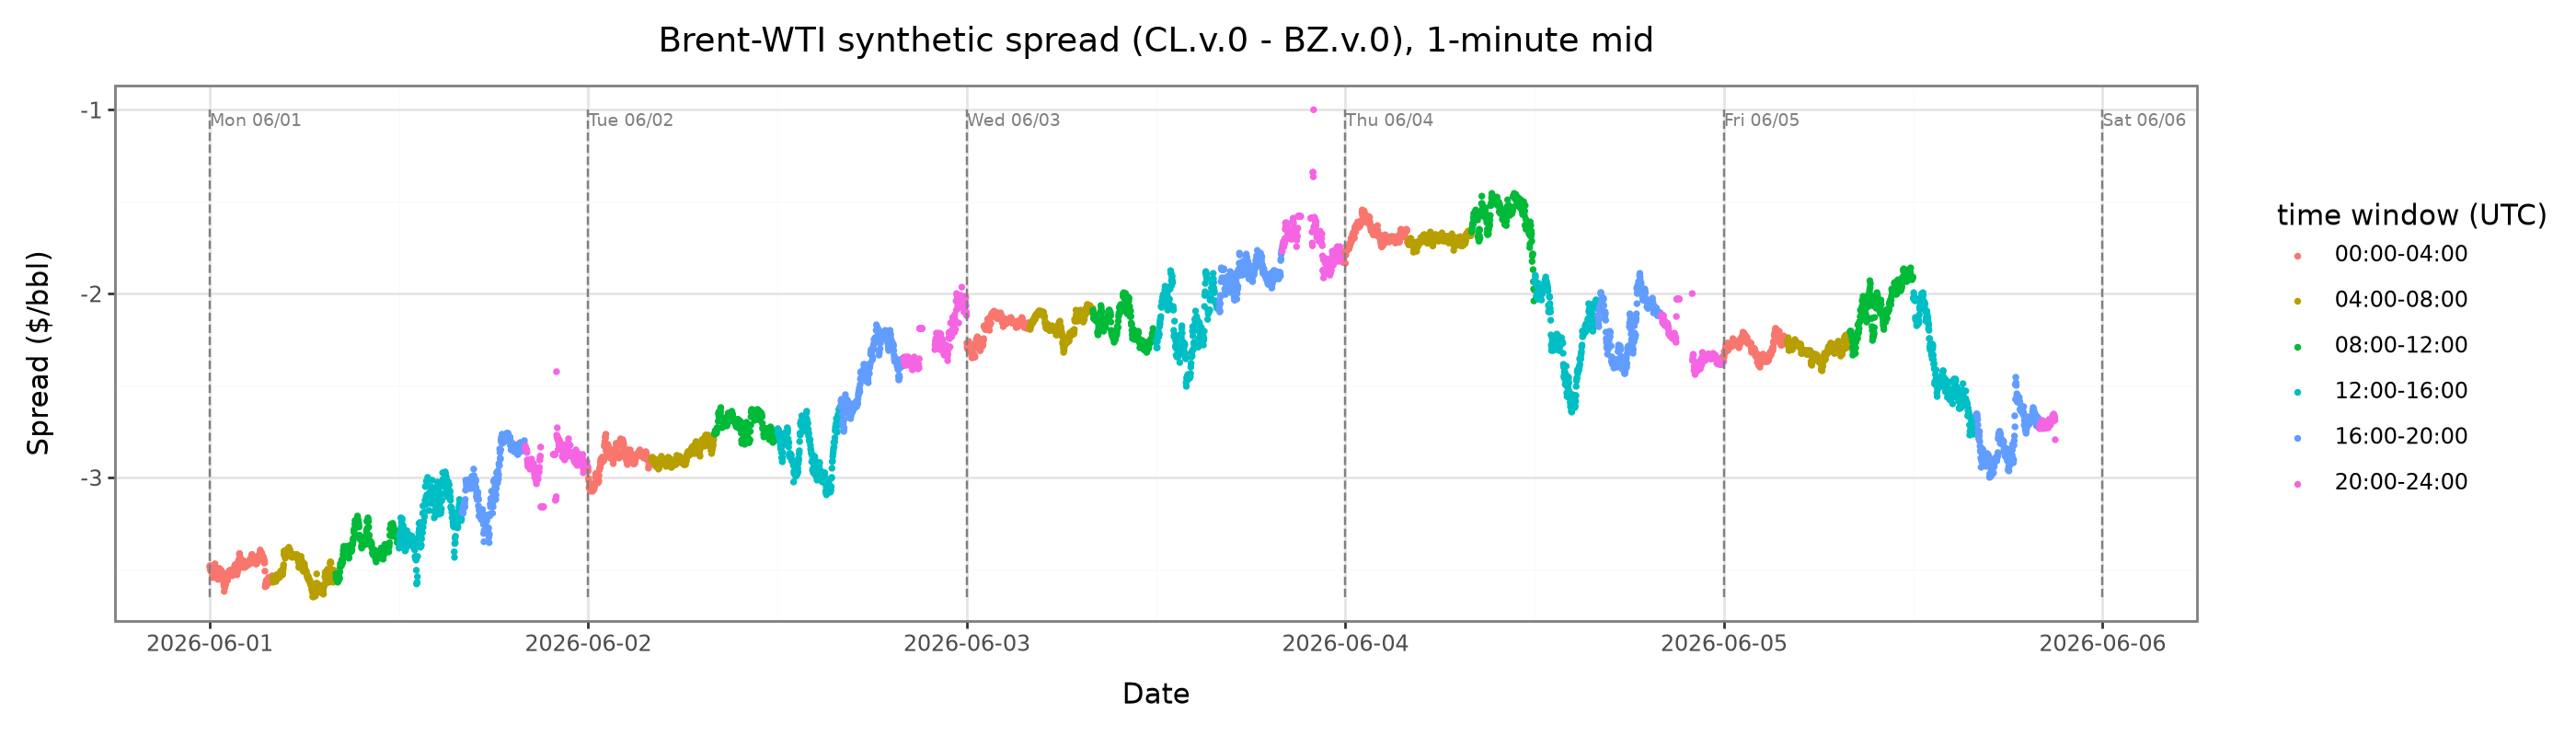

In [4]:
synth = aligned["synth_mid"].dropna()
plot_week_series(
    synth,
    "Brent-WTI synthetic spread (CL.v.0 - BZ.v.0), 1-minute mid",
    "Spread ($/bbl)",
)

Deviations from trailing means at three horizons (30 min, 2 h, 1 day).
Each panel shows the spread minus its own rolling mean — the raw material
for any mean-reversion signal:

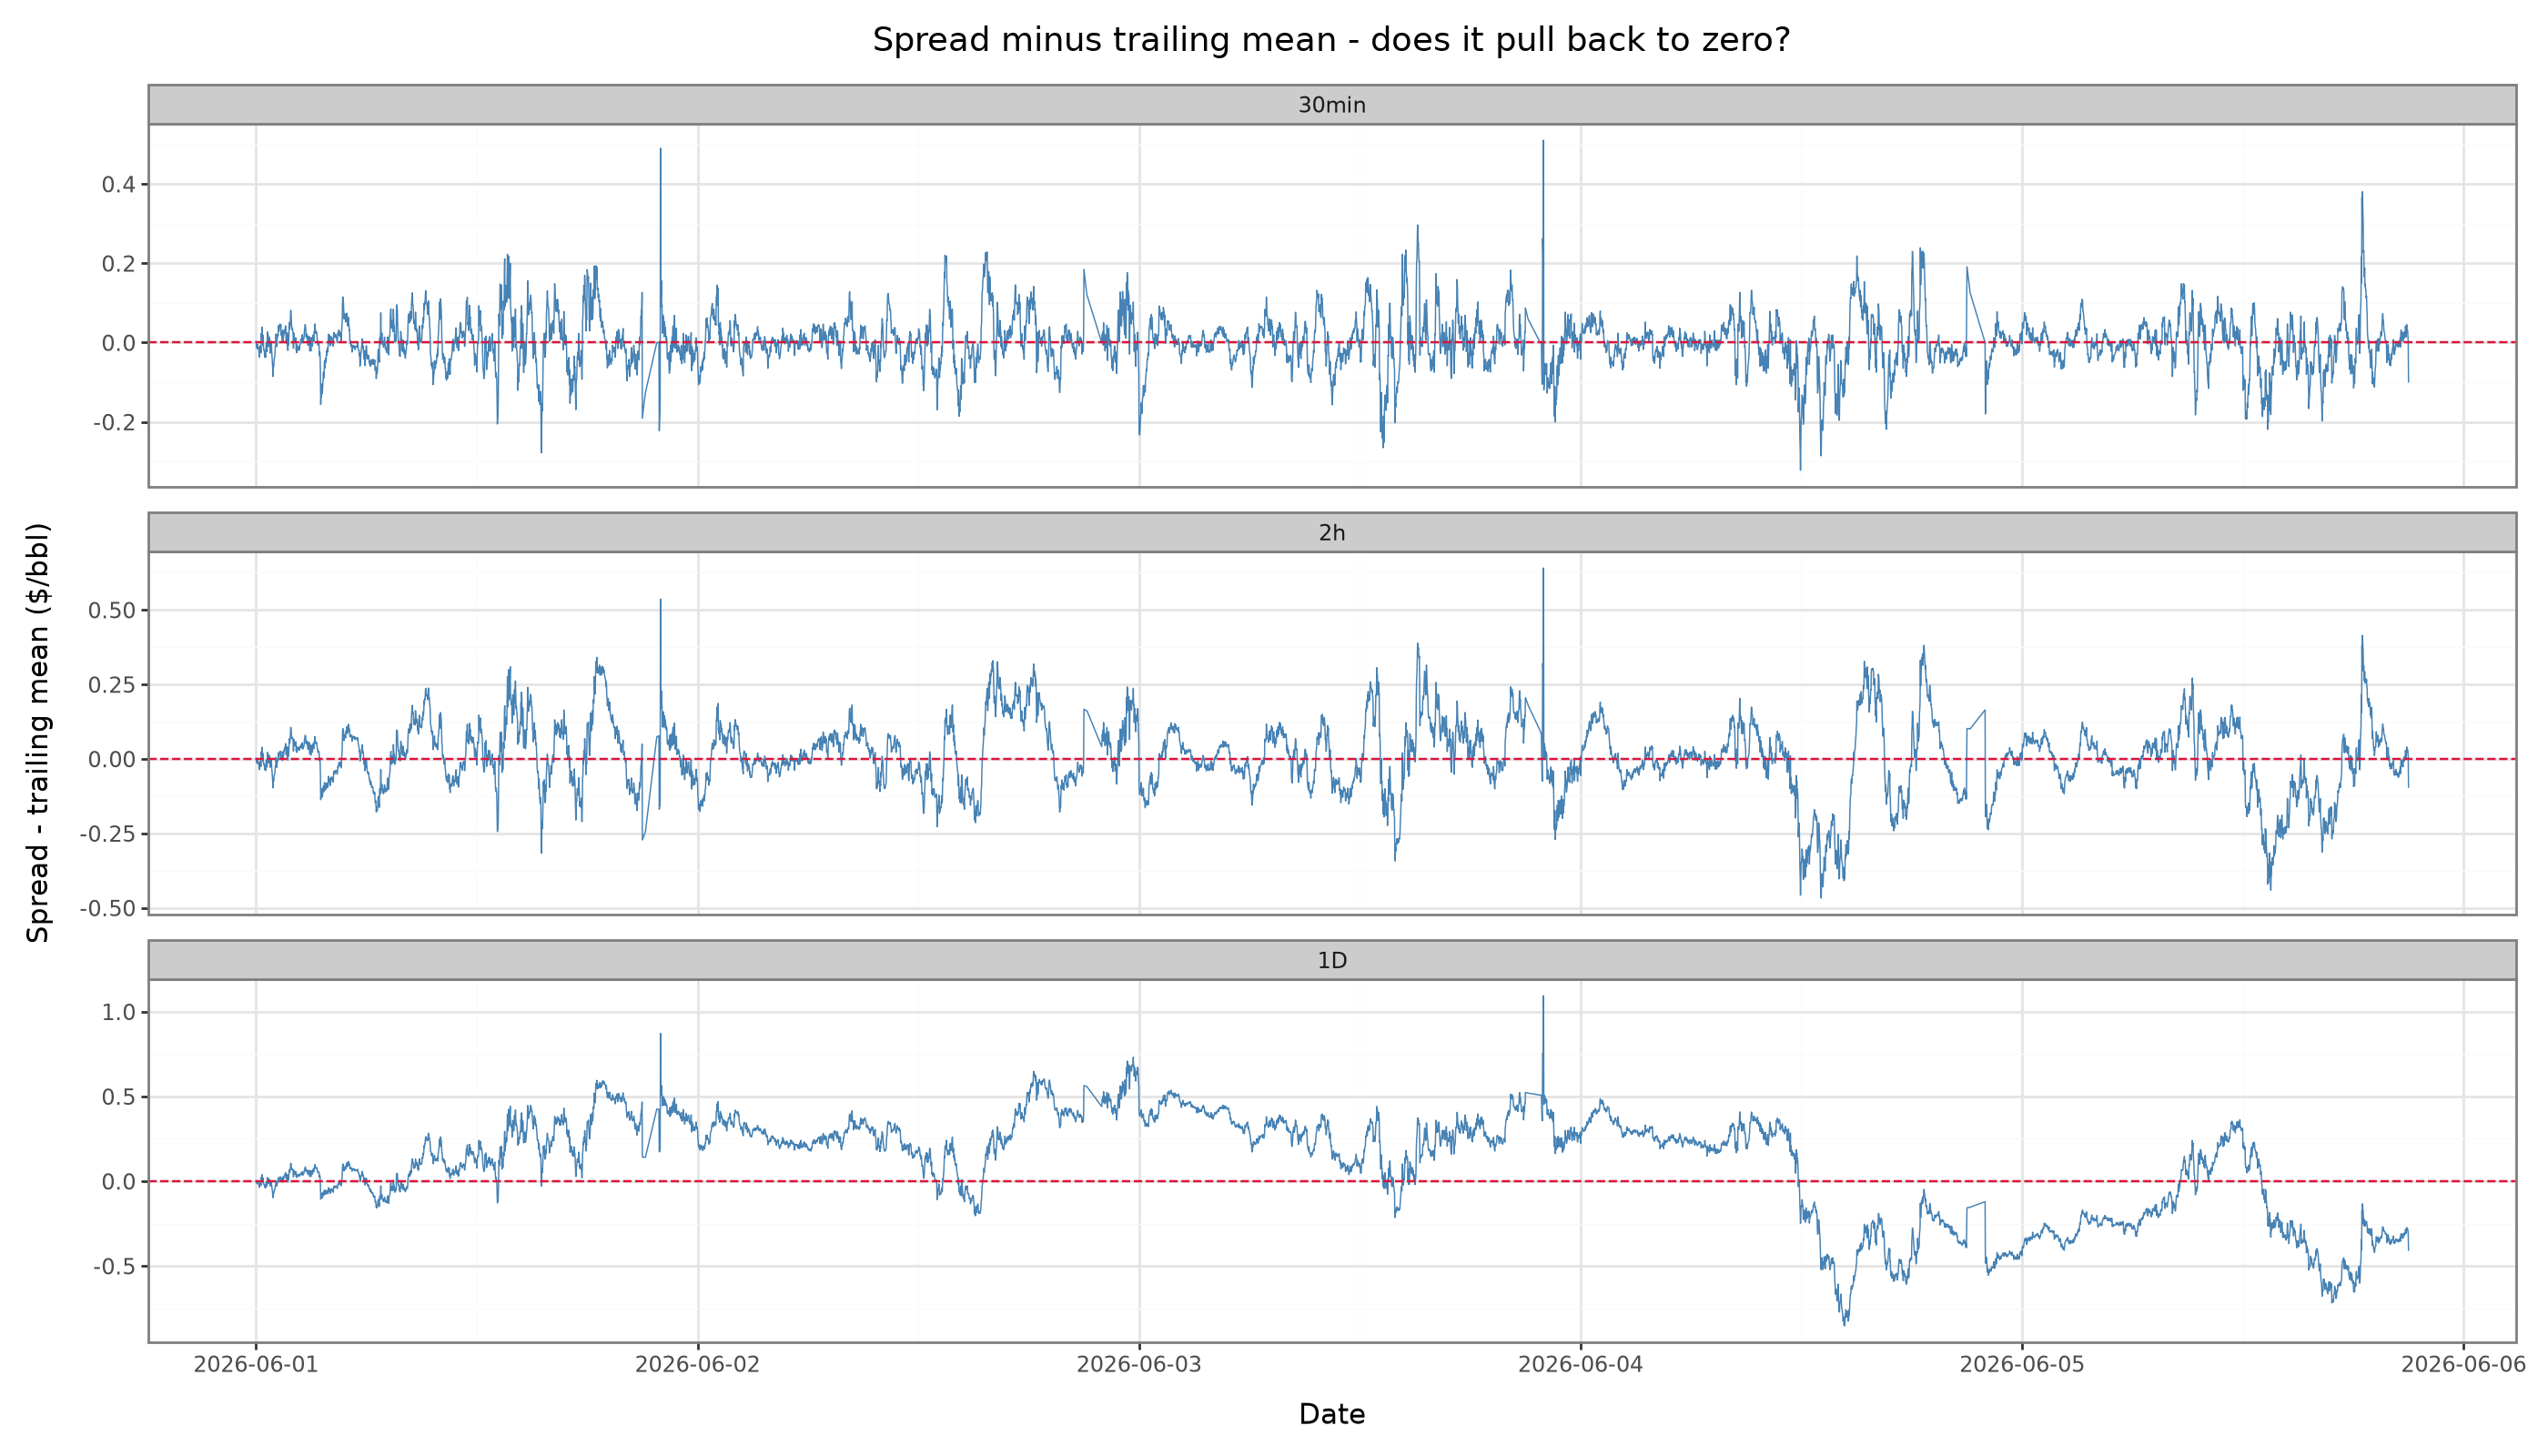

In [5]:
plot_rolling_deviations(synth, "Spread minus trailing mean - does it pull back to zero?")

The distribution of 2-hour-window deviations, with quantile markers — this
is the width of the band a reversion strategy would trade against:

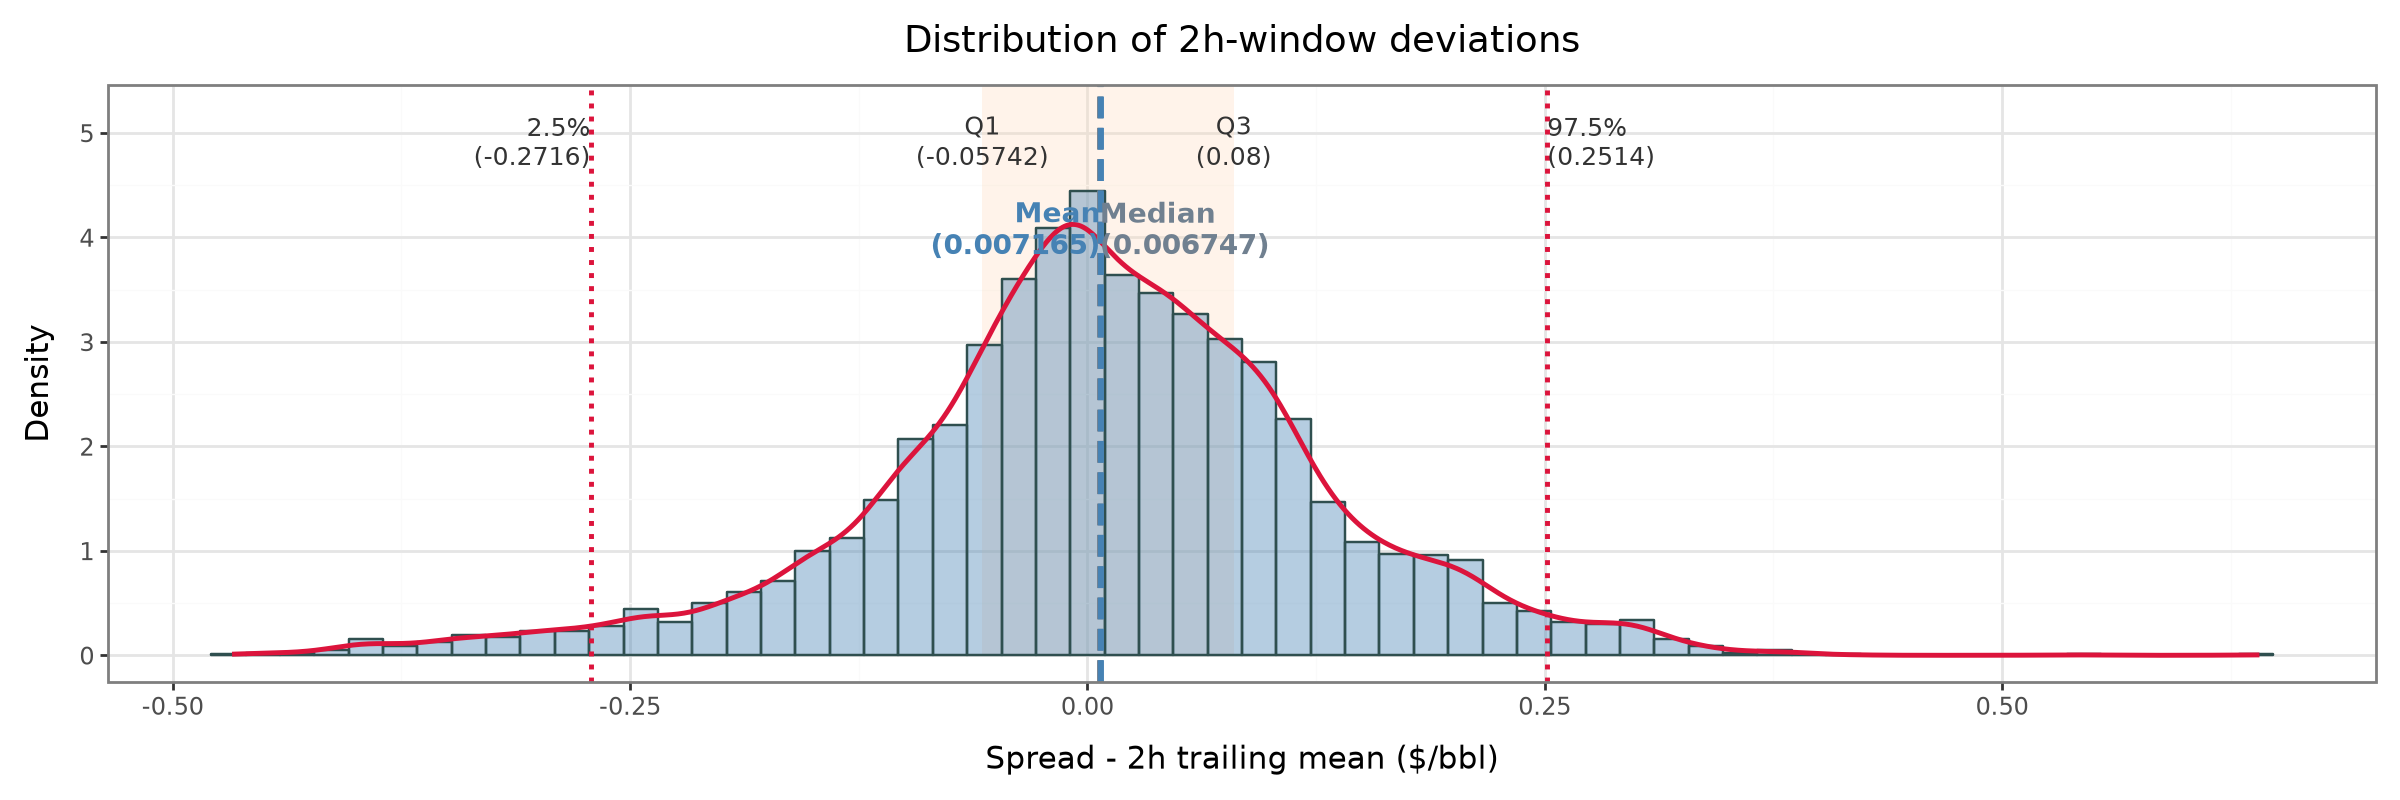

In [6]:
dev_2h = rolling_deviations(synth, ["2h"])["deviation"]
plot_histogram(
    dev_2h,
    "Distribution of 2h-window deviations",
    "Spread - 2h trailing mean ($/bbl)",
)

Partial autocorrelation of the deviation series at 1-minute lags — how much
of the current deviation is explained by recent history:

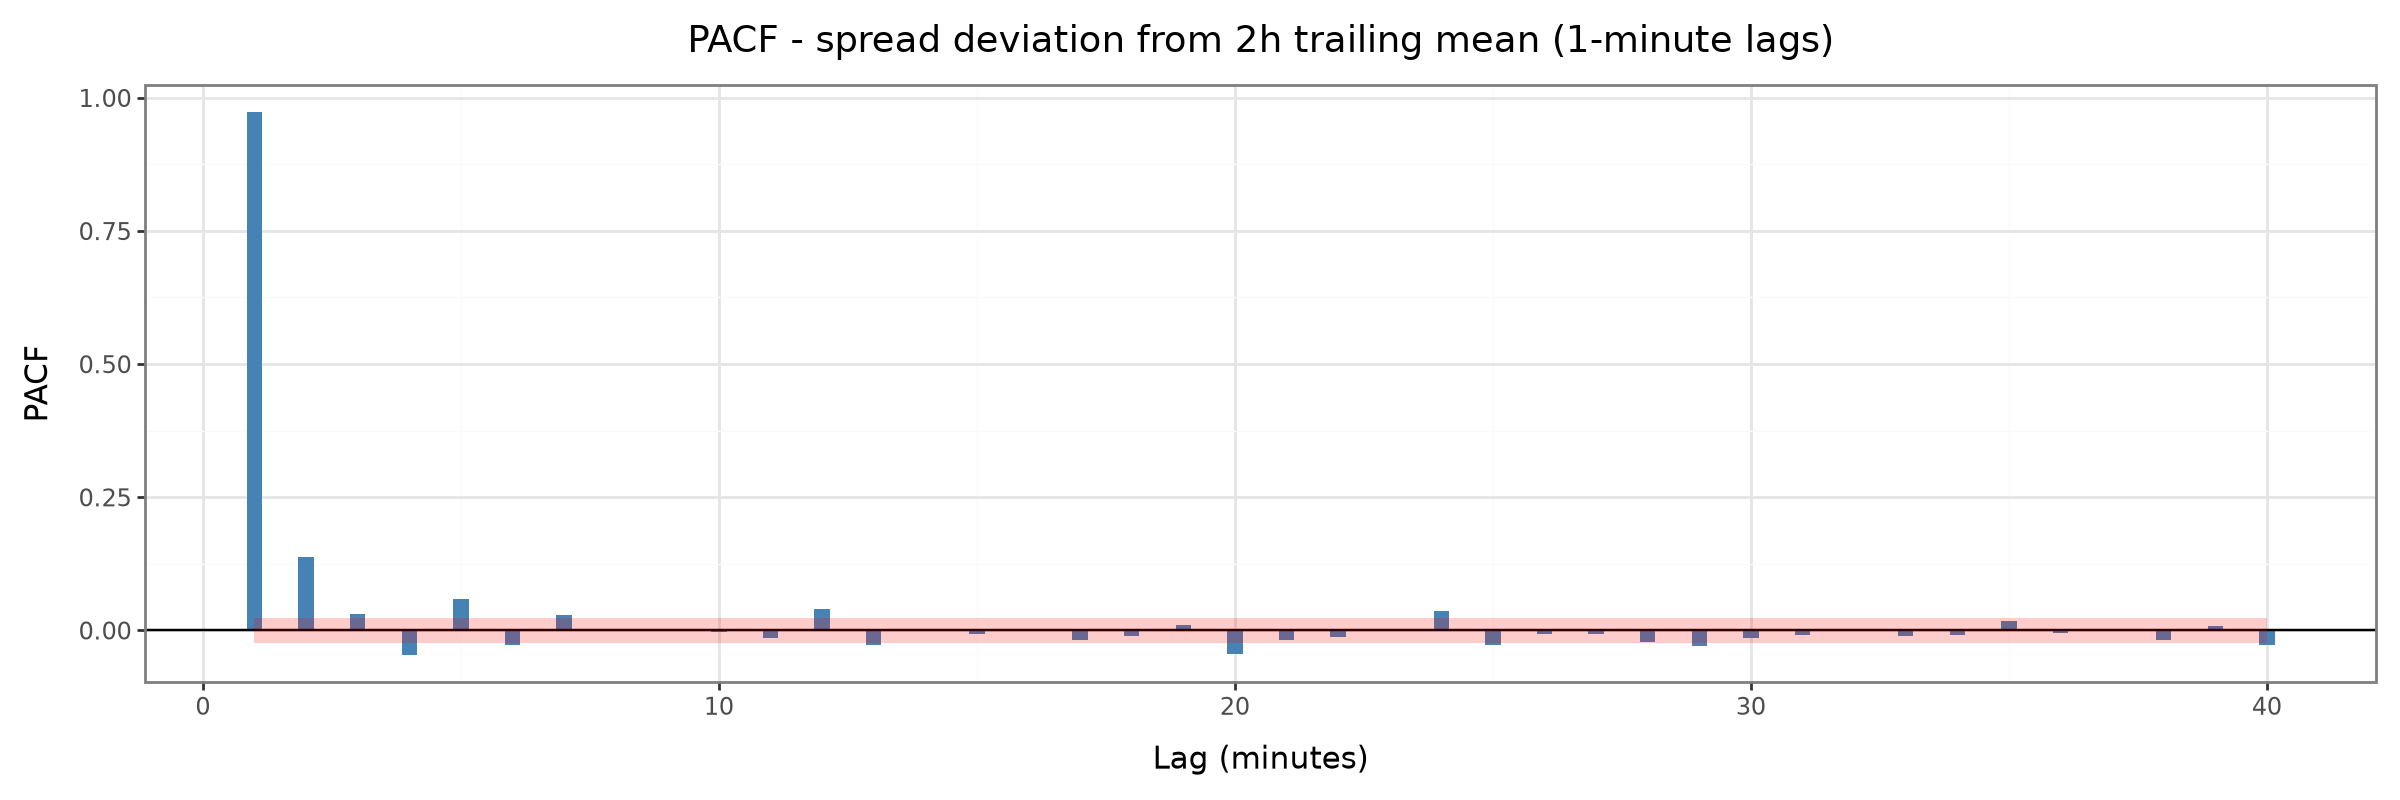

In [7]:
plot_pacf(dev_2h, "PACF - spread deviation from 2h trailing mean (1-minute lags)")

## 4. Liquidity: when and where the spread trades

Median top-of-book events per hour of day for every instrument (log scale).
This shows which hours have live books on all legs at once:

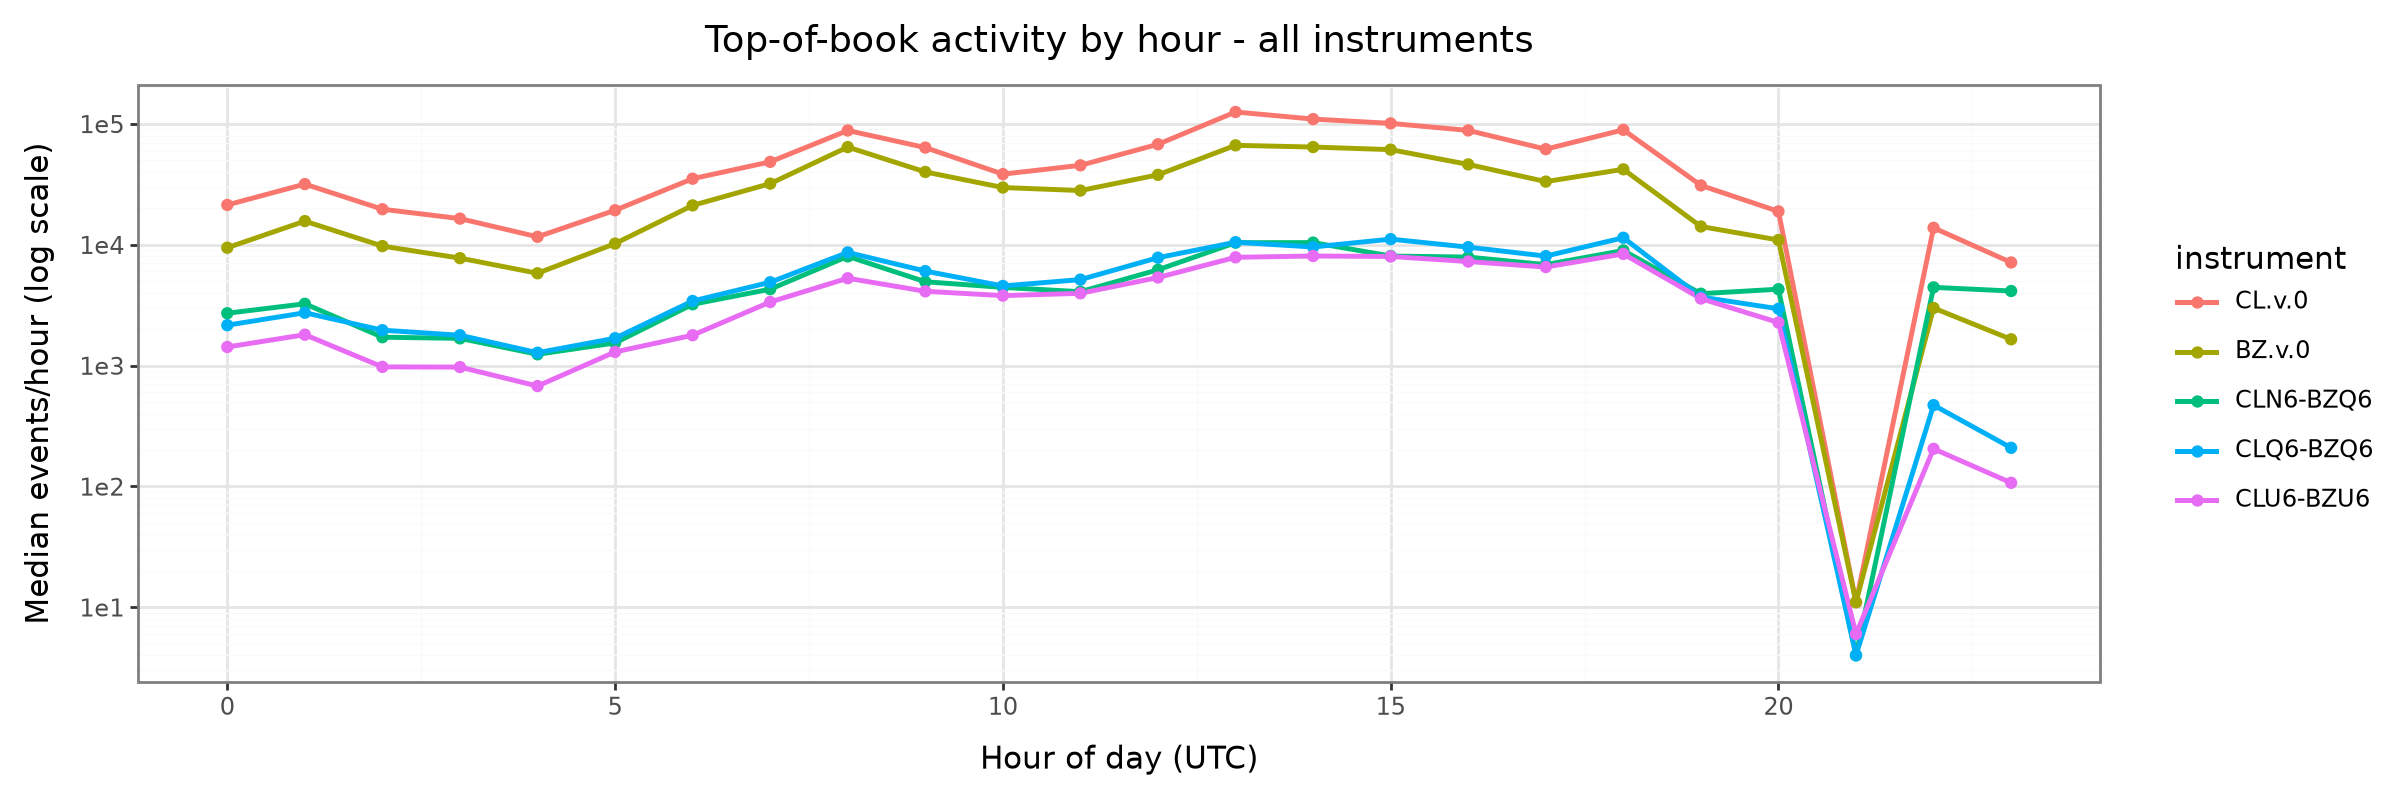

In [8]:
plot_activity_by_hour()

Execution cost by hour: the quoted width of the *synthetic* spread (crossing
both leg books) versus the *listed* spread instruments' own books. This
comparison is what decides which venue a fill model should assume:

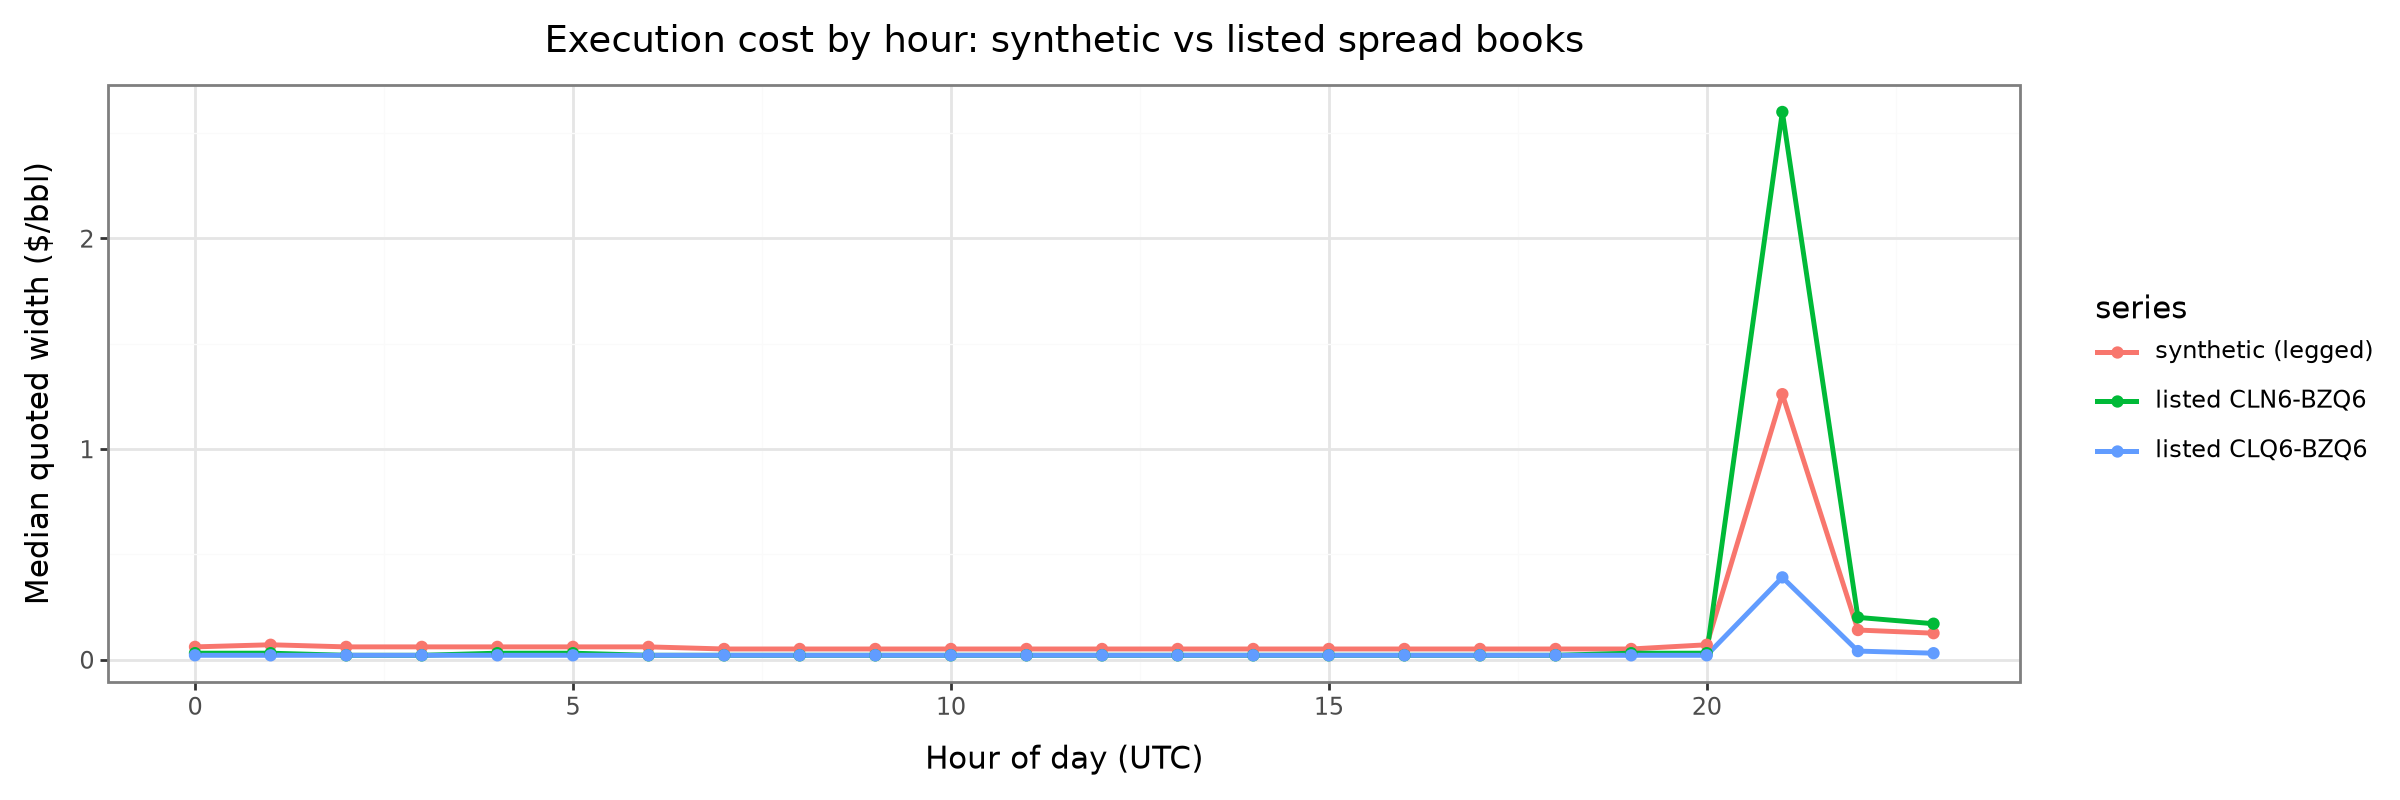

In [9]:
plot_width_by_hour(aligned)

## 5. Finer-grained data

The 1-minute aligned grid above is the convenient view. Two finer layers
exist for signal work and microstructure checks.

**1-second grids**, same layout, per instrument:

In [10]:
cl_1s = load_grid("CL.v.0", "1s")
print(f"CL.v.0 1s grid: {cl_1s.shape[0]:,} rows")
cl_1s.head(3)

CL.v.0 1s grid: 421,201 rows


,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,mid,instrument_id,n_events,n_trades,volume,is_roll_date
ts_recv,,,,,,,,,,
2026-06-01 00:00:00+00:00,89.42,89.44,1.0,2.0,89.43,777566.0,24,2,2,False
2026-06-01 00:00:01+00:00,89.42,89.44,2.0,1.0,89.43,777566.0,28,8,9,False
2026-06-01 00:00:02+00:00,89.42,89.44,2.0,2.0,89.43,777566.0,5,0,0,False


**Raw event series** for the listed spread instruments — every top-of-book
event with action/side/price/size, exactly as the book evolved:

In [11]:
events = load_spread_events(FRONT_SPREAD)
print(f"{FRONT_SPREAD}: {len(events):,} events over the week")
events.head(3)

CLN6-BZQ6: 624,789 events over the week


,instrument_id,action,side,price,size,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,mid,is_crossed
ts_recv,,,,,,,,,,,
2026-06-01 00:00:00+00:00,42016777,A,N,-3.46,2,-3.49,-3.47,2,2,-3.48,False
2026-06-01 00:00:00.135228895+00:00,42016777,C,A,-3.47,1,-3.49,-3.47,2,1,-3.48,False
2026-06-01 00:00:00.673503448+00:00,42016777,M,A,-3.47,1,-3.49,-3.47,2,2,-3.48,False


## 6. Loading the data in your own code

```python
from clean_mbp1 import load_aligned, load_grid, load_spread_events

aligned = load_aligned("1m")          # or "1s"
cl      = load_grid("CL.v.0", "1s")   # per-instrument grid
events  = load_spread_events()        # front listed spread, raw events
```

## 7. Regenerating from scratch

Requires `DATABENTO_API_KEY` in `.env` (the pull is billable, ~260 MB raw;
the DBN cache makes re-runs free):

```
doit pull_databento      # Databento -> DBN cache
doit clean_mbp1          # cache -> parquet (grids, events, aligned)
doit spread_diagnostics  # figures -> _output/figures
```

Layout, conventions, and instrument details: `data_manual/data_README.md`.